# Image Classification Using Traditional ML Algorithms

Objective: Implement and compare SVM and KNN classifiers for image classification, focusing on preprocessing, feature engineering, and model evaluation.

In [ ]:
#select a dataset from the suggested ones
#i will use MNIST Fashion dataset
#first import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml

# Load the dataset
mnist = fetch_openml('Fashion-MNIST', version=1, as_frame=False)

# Extract features (X) and target (y)
X = mnist.data
y = mnist.target

Imported needed libraries included *sklearn.datasets.fetch_openml* that is used to load datasets from OpenML, a repository for machine learning data.

We use *fetch_openml* to download the Fashion-MNIST dataset from OpenML,, version=1 specifies version of the dataset to load,, as_frame=False instructs the function to return the data as a Numpy array instead of a pandas dataframe

X=mnist.data is for extracting the features (pixel values of the images) from the loaded dataset and assigning them to variable X
y=mnist.target is for extracting target labels(type of clothing each image represents) and assigning them to variable y



In [ ]:
#next, Preprocess images (resizing, grayscale conversion, normalization).
from skimage.io import imread
from skimage.transform import resize
import numpy as np

def preprocess_image(img_path, target_size=(28,28)):
    img = imread(img_path, as_gray=True)  # Read as black & white
    img_resized = resize(img, target_size)  # Make all same size
    img_flat = img_resized.flatten()  # Stretch into one line
    # Add normalization here
    img_normalized = img_flat / 255.0  # Assuming pixel values are 0-255

    return img_normalized

This step involves preparing images for use in machine learning models

first step, we import libraries;
- imread is used to read an image file from given path(img_path)
- resize is used to resize the image to the desired target size
- numpy(np) provides numerical tools for operation esp arrays

- defining the preprocess image: this function takes the img_path and the desired target size(I used default 28,28) as input
- *img=imread(img_path, as_gray=True)* reads the image from the given path in grayscale
- *img_resized=resize(img,target_size) *resizes the image to the specified target size
- *img_flat=img_resized.flatten() *converts the 2D image array into a 1D array by flattening it
- *img_normalized=img_flat/255.0 * normalizes the pixel values to a range between 0 and 1 by dividing them by 255 (assuming the original pixels are in the range 0-255)
- *return img_normalized* returns the preprocessed image as a normalized 1D array

The preprocess_image function takes an image path, reads it in grayscale, resizes it to a consistent size, flattens it into a 1D array, and normalizes the pixel values. This process ensures that all images are in a standard format that can be readily used by machine learning algorithms.

In [ ]:
# Extract features using HOG, LBP, or other methods.
from skimage.feature import hog
from skimage.transform import resize

# Instead of using image paths, directly use the image data from X
def extract_hog_features_from_data(img_data):
    """
    Extracts HOG features directly from image data.

    Args:
        img_data (numpy.ndarray): Image data as a NumPy array.

    Returns:
        numpy.ndarray: HOG feature vector.
    """
    # Reshape the image data to 28x28
    img_resized = img_data.reshape(28, 28)

    # Calculate HOG features, explicitly specifying 'channel_axis=None'
    fd, hog_image = hog(img_resized, orientations=9, pixels_per_cell=(8, 8),
                        cells_per_block=(2, 2), visualize=True, channel_axis=None) #This removes multi-channel error

    return fd

## Feature Extraction using HOG
Focuses on extracting features from the images using the Histogram of Oriented Gradients (HOG) method. This step transforms raw pixel data into a more informative representation that machine learning models can effectively learn from.

so, we imported hog and resize functions from skimage module.
- *extract_hog_features_from_data* function takes image data(img_data) as input which is expected to be a numpy array
- *img_resized=img_data.reshape(28,28)* reshapes the 1D img_data into 28,28 2D array representing the image
- fd, hog_image=hog(...) calculates HOG features using the hog function, which has parameters:
1. orientations=9: number of gradient orientations to consider(how many directions of edges to detect)
2. pixels_per_cell=(8,8); size of the cells used to divide the image for HOG calculation
3. cells_per_block(2,2); size of the blocks of cells used for normalization
4. visualize=True; tells the hog function to also return a visualization of the HOG features(hog_image) though it is not used in this specific part of code
5. channel_axis=none; important for grayscale images as it tells hog there are no color channels to consider
- return fd; fucntion to return the calculated HOG feature vector fd

The extract_hog_features_from_data function takes image data as input, reshapes it into a 2D image, and then applies the HOG algorithm to extract features. These features capture information about the distribution of gradient orientations in the image, which can be helpful for tasks like object detection and image classification. The extracted features are then returned as a feature vector.




In [ ]:
# Train and evaluate SVM and KNN models
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Extract features directly from image data
X_features = [extract_hog_features_from_data(img_data) for img_data in X]
X_train, X_test, y_train, y_test = train_test_split(X_features, y, test_size=0.25, random_state=42)
#with a linear kernel
svm_classifier = SVC(kernel='linear')
svm_classifier.fit(X_train, y_train)

SVC(kernel='linear')

This sstep focuses on training a Support Vector Machine (SVM) classifier using the HOG features extracted from the images. also involves splitting the data into training and testing sets for model evaluation

- X_features = *[extract_hog_features_from_data(img_data) for img_data in X]*: This line applies the extract_hog_features_from_data function to each image in your dataset X (which we loaded earlier) to extract HOG features. The result is stored in X_features.

- X_train, X_test, y_train, y_test = *train_test_split(X_features, y, test_size=0.25, random_state=42)*: This line splits our data and labels (X_features and y) into training and testing sets:
1. test_size=0.25: 25% of the data is used for testing.
2. random_state=42: Ensures consistent splitting for reproducibility.

SVM Classifier Training

svm_classifier = SVC(kernel='linear'): Creates an instance of the Support Vector Classifier (SVC) with a linear kernel. The kernel determines how the model separates data points in higher dimensions.
svm_classifier.fit(X_train, y_train): This line trains the SVM classifier using the training data (X_train for features, y_train for labels). The model learns patterns from the training data to make predictions on unseen data.

This step extracts HOG features from the images, splits the data into training and testing sets, and then trains an SVM classifier with a linear kernel using the training data. The trained SVM model is now ready to be used for making predictions on new images.

In [ ]:
# training with with 5 neighbors
knn_classifier = KNeighborsClassifier(n_neighbors=5).fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=5): This creates an instance of the KNN classifier from scikit-learn.

The *n_neighbors=5* parameter specifies that the algorithm should consider the 5 nearest neighbors when making a prediction. This means that for a new data point, the algorithm will look at the 5 data points in the training set that are most similar to it and use their labels to predict the label of the new data point.

*.fit(X_train, y_train)*: This part of the code actually trains the KNN classifier using the training data:

X_train: This is the training data containing the HOG features extracted from the images.
y_train: This contains the corresponding labels for the training images.


In [ ]:
#then predictions
svm_predictions = svm_classifier.predict(X_test)
knn_predictions = knn_classifier.predict(X_test)

In [ ]:
#Compare results using accuracy, confusion matrices, and classification reports
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

#then evaluate results
svm_accuracy = accuracy_score(y_test, svm_predictions)
knn_accuracy = accuracy_score(y_test, knn_predictions)
print("SVM Accuracy:", svm_accuracy)
print("KNN Accuracy:", knn_accuracy)



SVM Accuracy: 0.8274857142857143
KNN Accuracy: 0.8136571428571429


SVM Accuracy: The SVM model achieved an accuracy of approximately 82.75%. This means that out of all the images in the test set, the SVM model correctly classified about 82.75% of them.
KNN Accuracy: The KNN model achieved an accuracy of approximately 81.37%. This means that it correctly classified about 81.37% of the images in the test set.
Comparison:

In this case, the SVM model slightly outperformed the KNN model in terms of accuracy. The difference in accuracy is about 1.38%, which might be considered a small but potentially significant improvement, depending on the specific application and requirements.

In [ ]:
#print classification reports
svm_report = classification_report(y_test, svm_predictions)
knn_report = classification_report(y_test, knn_predictions)
print("SVM Classification Report: \n", svm_report)
print("\nKNN Classification Report: \n", knn_report)

SVM Classification Report: 
               precision    recall  f1-score   support

           0       0.76      0.83      0.79      1736
           1       0.97      0.95      0.96      1729
           2       0.73      0.68      0.70      1772
           3       0.83      0.85      0.84      1804
           4       0.68      0.73      0.70      1721
           5       0.93      0.92      0.92      1793
           6       0.56      0.50      0.53      1760
           7       0.90      0.91      0.91      1714
           8       0.96      0.96      0.96      1703
           9       0.95      0.95      0.95      1768

    accuracy                           0.83     17500
   macro avg       0.83      0.83      0.83     17500
weighted avg       0.83      0.83      0.83     17500


KNN Classification Report: 
               precision    recall  f1-score   support

           0       0.76      0.80      0.78      1736
           1       0.94      0.96      0.95      1729
           2       

The SVM model achieved an accuracy of 83%, indicating good overall performance.
Class-wise: The model performs very well for classes 1, 5, 8, and 9 (precision and recall above 0.9). It has moderate performance for classes 0, 3, and 4. Class 6 shows the lowest performance, with precision and recall around 0.5.

The KNN model has an accuracy of 81%, slightly lower than the SVM.
Class-wise: Similar to SVM, KNN performs well for classes 1, 8, and 9. It has moderate performance for classes 0, 3, and 7. Classes 2, 4, and 6 show lower performance, especially class 6 with precision and recall around 0.5.

Comparison:

SVM generally has slightly better precision and recall for most classes compared to KNN.
Both models struggle with class 6, indicating potential difficulties in classifying that specific category of clothing in the Fashion-MNIST dataset.
KNN achieves higher recall for class 7 but lower precision than SVM.

In [ ]:
#generate and print confusion matrices
svm_conf_matrix = confusion_matrix(y_test, svm_predictions)
knn_conf_matrix = confusion_matrix(y_test, knn_predictions)
print("SVM Confusion Matrix: \n", svm_conf_matrix)
print("\nKNN Confusion Matrix: \n", knn_conf_matrix)

SVM Confusion Matrix: 
 [[1437    9   48   64   19    0  140    0   19    0]
 [   5 1642    6   55    6    0   14    0    1    0]
 [  34    2 1209   23  244    0  247    0   13    0]
 [  59   34   21 1533   89    0   65    0    3    0]
 [   5    2  167   87 1257    1  199    0    3    0]
 [   0    0    0    4    0 1657    0  104    2   26]
 [ 349    5  207   63  230    0  882    0   24    0]
 [   0    0    0    0    0   97    0 1562    0   55]
 [   9    1    9   11    6   13   25    0 1627    2]
 [   0    0    0    0    0   22    0   71    0 1675]]

KNN Confusion Matrix: 
 [[1389   17   67   51   36    0  163    0   13    0]
 [   7 1656    7   44    5    0    9    0    1    0]
 [  54    3 1225   22  284    0  182    0    2    0]
 [  53   70   39 1477  116    0   49    0    0    0]
 [   9    9  200   79 1210    0  208    1    5    0]
 [   1    0    1    8    1 1543    0  196    0   43]
 [ 311   10  208   57  289    0  874    0   11    0]
 [   0    0    0    0    0   58    0 1587    0   

Diagonal elements represent correct classifications. For example, 1437 instances of class 0 were correctly classified as class 0.
Off-diagonal elements represent

misclassifications. For example, 48 instances of class 0 were incorrectly classified as class 2.

Class 6 (row 6) appears to be the most challenging for the SVM model, with a high number of misclassifications across multiple other classes.

KNN

Similar to the SVM, the diagonal elements show correct classifications, and off-diagonal elements represent errors.

Class 6 (row 6) is also challenging for the KNN model, with significant misclassifications.
KNN seems to have more misclassifications for class 4 (row 4) compared to SVM.

Comparison:

Both models exhibit similar patterns of misclassifications, particularly for class 6.
SVM generally appears to have slightly fewer misclassifications for most classes compared to KNN.
Analyzing specific off-diagonal elements can reveal which classes are often confused with each other by each model.

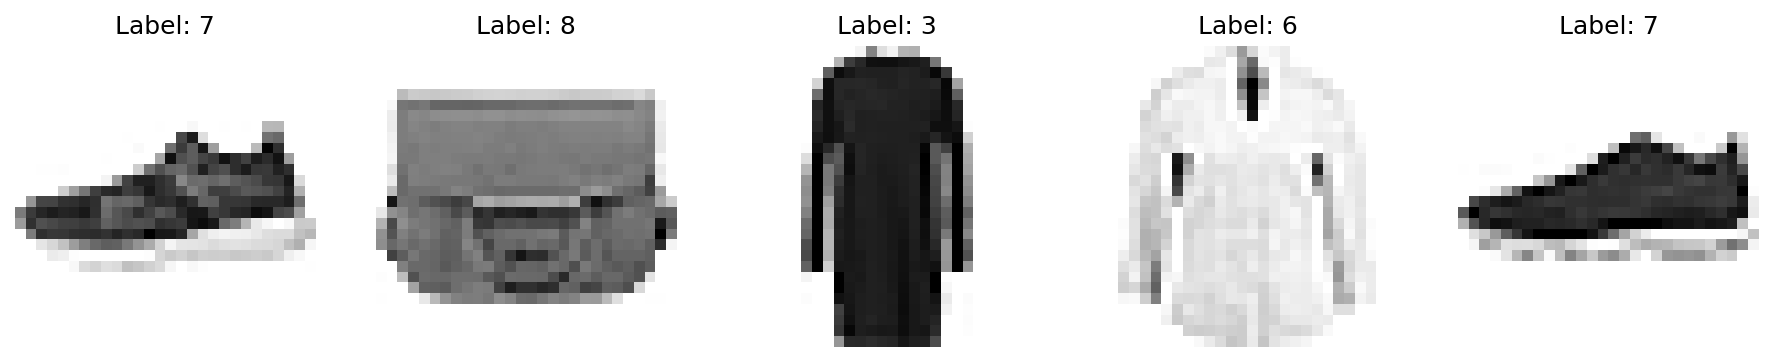

In [ ]:
# Select a few random images to display
num_images_to_display = 5
random_indices = np.random.choice(len(X), num_images_to_display, replace=False)

# Display the images
plt.figure(figsize=(15, 6), dpi=150)  # Adjust figure size as needed
for i, index in enumerate(random_indices):
    plt.subplot(1, num_images_to_display, i + 1)
    plt.imshow(X[index].reshape(28, 28), cmap='binary')  # Reshape to 28x28 and use grayscale
    plt.title(f"Label: {y[index]}")  # Display the label
    plt.axis('off')  # Hide axes

plt.show()

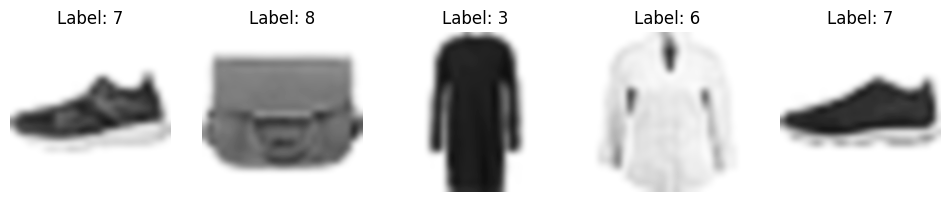

In [ ]:
plt.figure(figsize=(12, 5), dpi=100)  # Increased figure size and DPI
for i, index in enumerate(random_indices):
    plt.subplot(1, num_images_to_display, i + 1)
    plt.imshow(X[index].reshape(28, 28), cmap='binary', interpolation='bicubic')
    plt.title(f"Label: {y[index]}")
    plt.axis('off')

plt.show()